# Nettoyage et préparation des données
Objectif : rendre le jeu de données `delivery_data.csv` exploitable pour prédire `Time_taken(min)`, le temps de livraison en minutes. Chaque décision de nettoyage est justifiée.

## 1. Importation des packages
Import de pandas et numpy (manipulation des données), matplotlib et seaborn (visualisation), et `global_land_mask` (vérification des coordonnées GPS).

In [538]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from deliveryeta.paths import DELIVERY_DATA_B, DELIVERY_DATA_S
from global_land_mask import globe

## 2. Chargement du fichier
Chargement du fichier brut depuis `data/bronze/`. Le fichier original n'est jamais modifié ; les données nettoyées seront sauvegardées dans `data/silver/`.

In [539]:
df = pd.read_csv(DELIVERY_DATA_B)
df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30


## 3. Informations générales sur le jeu de données
Le jeu brut contient **45 593 lignes et 20 colonnes** : identifiant de commande, informations sur le livreur, coordonnées GPS du restaurant et du client, dates et heures, météo, trafic, véhicule, type de commande, nombre de livraisons simultanées, et la variable cible `Time_taken(min)`.

In [540]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  object 
 1   Delivery_person_ID           45593 non-null  object 
 2   Delivery_person_Age          45593 non-null  object 
 3   Delivery_person_Ratings      45593 non-null  object 
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  object 
 9   Time_Orderd                  45593 non-null  object 
 10  Time_Order_picked            45593 non-null  object 
 11  Weatherconditions            45593 non-null  object 
 12  Road_traffic_density         45593 non-null  object 
 13  Vehicle_conditio

,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Vehicle_condition
count,45593.000000,45593.000000,45593.000000,45593.000000,45593.000000
mean,17.017729,70.231332,17.465186,70.845702,1.023359
std,8.185109,22.883647,7.335122,21.118812,0.839065
min,-30.905562,-88.366217,0.010000,0.010000,0.000000
25%,12.933284,73.170000,12.988453,73.280000,0.000000
50%,18.546947,75.898497,18.633934,76.002574,1.000000
75%,22.728163,78.044095,22.785049,78.107044,2.000000
max,30.914057,88.433452,31.054057,88.563452,3.000000


## 4. Suppression des colonnes inutiles et correction des types

**Colonnes supprimées et pourquoi :**
- `Delivery_person_ID` : identifiant du livreur, non réutilisable comme variable prédictive.
- `Delivery_person_Age`, `Vehicle_condition`, `Type_of_order`, `Festival`, `City` : écartées pour garder un modèle simple avec un nombre limité de variables (décision projet).
- `Order_Date`, `Time_Orderd`, `Time_Order_picked` : la date/l'heure de commande ne sera pas utilisée comme variable d'entrée.

**Colonnes conservées :** `ID` (identifiant technique, exclu du modèle plus tard), `Delivery_person_Ratings`, les 4 coordonnées GPS, `Weatherconditions`, `Road_traffic_density`, `Type_of_vehicle`, `multiple_deliveries`, `Time_taken(min)` (cible).

In [541]:
df = df.drop(columns=[
    'Delivery_person_ID', 'Delivery_person_Age',
    'Order_Date', 'Time_Orderd', 'Time_Order_picked',
    'Vehicle_condition', 'Type_of_order', 'Festival', 'City'
])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  object 
 1   Delivery_person_Ratings      45593 non-null  object 
 2   Restaurant_latitude          45593 non-null  float64
 3   Restaurant_longitude         45593 non-null  float64
 4   Delivery_location_latitude   45593 non-null  float64
 5   Delivery_location_longitude  45593 non-null  float64
 6   Weatherconditions            45593 non-null  object 
 7   Road_traffic_density         45593 non-null  object 
 8   Type_of_vehicle              45593 non-null  object 
 9   multiple_deliveries          45593 non-null  object 
 10  Time_taken(min)              45593 non-null  object 
dtypes: float64(4), object(7)
memory usage: 3.8+ MB


## 5. Nettoyage du texte parasite

Plusieurs colonnes contiennent du texte parasite qui empêche leur bon typage :
- `Time_taken(min)` : valeurs de la forme `"(min) 24"` au lieu de `24`.
- `Weatherconditions` : valeurs de la forme `"conditions Sunny"` au lieu de `"Sunny"`.
- `Road_traffic_density`, `Delivery_person_Ratings`, `multiple_deliveries`, `Type_of_vehicle` : espaces parasites en fin de valeur (ex. `"High "` au lieu de `"High"`).
- Les valeurs manquantes ne sont **pas** de vrais `NaN` mais le texte littéral `"NaN"` (ou `"conditions NaN"`, `"NaN "`), donc invisibles pour `.isna()` tant qu'elles ne sont pas converties.

**Point important sur les types :** ce projet utilise pandas 3.0, où les colonnes texte sont chargées avec le dtype `str` (le nouveau backend string), et non plus `object` comme dans les versions précédentes de pandas. Un test du type `if df[col].dtype == 'object'` ne détecte donc jamais ces colonnes ici — le nettoyage est appliqué directement, sans ce test.

La fonction `fixing_Data` corrige toutes ces colonnes.

In [542]:
def fixing_Data(df):
    # Time_taken(min) : retirer le préfixe "(min) " et convertir en entier
    df['Time_taken(min)'] = df['Time_taken(min)'].str.replace('(min) ', '', regex=False)
    df['Time_taken(min)'] = pd.to_numeric(df['Time_taken(min)'], errors='coerce').astype('Int64')

    # Weatherconditions : retirer le préfixe "conditions " et convertir "NaN" en vrai NaN
    df['Weatherconditions'] = df['Weatherconditions'].str.replace('conditions ', '', regex=False)
    df['Weatherconditions'] = df['Weatherconditions'].replace('NaN', np.nan)

    # Road_traffic_density : retirer les espaces parasites et convertir "NaN" en vrai NaN
    df['Road_traffic_density'] = df['Road_traffic_density'].str.strip()
    df['Road_traffic_density'] = df['Road_traffic_density'].replace('NaN', np.nan)

    # Type_of_vehicle : retirer les espaces parasites
    df['Type_of_vehicle'] = df['Type_of_vehicle'].str.strip()

    # Delivery_person_Ratings : nettoyer puis convertir en nombre décimal
    df['Delivery_person_Ratings'] = df['Delivery_person_Ratings'].str.strip().replace('NaN', np.nan)
    df['Delivery_person_Ratings'] = pd.to_numeric(df['Delivery_person_Ratings'], errors='coerce').astype('Float64')

    # multiple_deliveries : nettoyer puis convertir en entier
    df['multiple_deliveries'] = df['multiple_deliveries'].str.strip().replace('NaN', np.nan)
    df['multiple_deliveries'] = pd.to_numeric(df['multiple_deliveries'], errors='coerce').astype('Int64')

    return df

df = fixing_Data(df)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  object 
 1   Delivery_person_Ratings      43685 non-null  Float64
 2   Restaurant_latitude          45593 non-null  float64
 3   Restaurant_longitude         45593 non-null  float64
 4   Delivery_location_latitude   45593 non-null  float64
 5   Delivery_location_longitude  45593 non-null  float64
 6   Weatherconditions            44977 non-null  object 
 7   Road_traffic_density         44992 non-null  object 
 8   Type_of_vehicle              45593 non-null  object 
 9   multiple_deliveries          44600 non-null  Int64  
 10  Time_taken(min)              45593 non-null  Int64  
dtypes: Float64(1), Int64(2), float64(4), object(4)
memory usage: 4.0+ MB


## 6. Filtrage des coordonnées GPS invalides

Certaines lignes ont des coordonnées de restaurant ou de client qui tombent dans l'océan (erreurs de saisie). La fonction `filter_lat_lon` utilise `global_land_mask` pour ne garder que les lignes où le restaurant **et** le point de livraison sont bien sur la terre ferme.

**Résultat : 45 593 → 39 831 lignes (5 762 lignes supprimées, soit 12,6 %).** C'est une proportion importante, mais ces lignes ont des coordonnées géographiquement impossibles (dans l'océan), donc inutilisables pour une prédiction basée sur la distance réelle.

In [543]:
def filter_lat_lon(df):
    df['isLandRestau'] = df.apply(
        lambda row: globe.is_land(row['Restaurant_latitude'], row['Restaurant_longitude']),
        axis=1
    )
    df['isLandDeli'] = df.apply(
        lambda row: globe.is_land(row['Delivery_location_latitude'], row['Delivery_location_longitude']),
        axis=1
    )
    df = df[df['isLandRestau'] & df['isLandDeli']]
    df = df.drop(columns=['isLandRestau', 'isLandDeli'])
    return df

before = len(df)
df = filter_lat_lon(df)
after = len(df)
print(f"Lignes avant filtrage GPS : {before}")
print(f"Lignes après filtrage GPS : {after}")
print(f"Lignes supprimées : {before - after} ({(before-after)/before*100:.1f} %)")

Lignes avant filtrage GPS : 45593
Lignes après filtrage GPS : 39831
Lignes supprimées : 5762 (12.6 %)


## 7. Séparation des variables

Séparation des colonnes restantes en variables numériques et catégorielles, en excluant `ID` (identifiant) et `Time_taken(min)` (cible).

In [544]:
id_col = "ID"
target = "Time_taken(min)"

num_cols = df.select_dtypes(include="number").columns.tolist()
for c in (id_col, target):
    if c in num_cols:
        num_cols.remove(c)

cat_cols = df.select_dtypes(include="object").columns.tolist() + \
           [c for c in df.columns if str(df[c].dtype) == "string" and c not in (id_col,)]
cat_cols = list(dict.fromkeys(cat_cols))  # dédoublonner en gardant l'ordre

print("Variable cible :", target)
print("Variables numériques :", num_cols)
print("Variables catégorielles :", cat_cols)

Variable cible : Time_taken(min)
Variables numériques : ['Delivery_person_Ratings', 'Restaurant_latitude', 'Restaurant_longitude', 'Delivery_location_latitude', 'Delivery_location_longitude', 'multiple_deliveries']
Variables catégorielles : ['ID', 'Weatherconditions', 'Road_traffic_density', 'Type_of_vehicle']


## 8. Valeurs uniques des variables catégorielles
Vérification des modalités de chaque variable catégorielle pour confirmer qu'il ne reste plus d'incohérence après le nettoyage.

In [545]:
for col in cat_cols:
    print(f"--- {col} ---")
    print(df[col].unique(), "\n")

--- ID ---
['0x4607 ' '0xb379 ' '0x5d6d ' ... '0x4f8d ' '0x5eee ' '0x5fb2 '] 

--- Weatherconditions ---
['Sunny' 'Stormy' 'Sandstorms' 'Cloudy' 'Fog' 'Windy' nan] 

--- Road_traffic_density ---
['High' 'Jam' 'Low' 'Medium' nan] 

--- Type_of_vehicle ---
['motorcycle' 'scooter' 'electric_scooter' 'bicycle'] 



## 9. Analyse des valeurs manquantes

### 9.1 Comptage et pourcentage

Quatre colonnes contiennent des valeurs manquantes après nettoyage du texte :

| Colonne | Valeurs manquantes | Pourcentage |
|---|---:|---:|
| `Delivery_person_Ratings` | 1 908 | 4,18 % |
| `Weatherconditions` | 616 | 1,35 % |
| `Road_traffic_density` | 601 | 1,32 % |
| `multiple_deliveries` | 993 | 2,18 % |

Ces proportions restent faibles (entre 1 % et 4,2 %), donc la suppression des lignes n'est pas nécessaire : l'imputation permet de conserver l'information des autres colonnes de ces lignes.

In [546]:
missing = df.isna().sum()
missing_pct = (df.isna().mean() * 100).round(2)
missing_summary = pd.DataFrame({"Valeurs manquantes": missing, "Pourcentage (%)": missing_pct})
missing_summary[missing_summary["Valeurs manquantes"] > 0]

,Valeurs manquantes,Pourcentage (%)
Delivery_person_Ratings,1480,3.72
Weatherconditions,418,1.05
Road_traffic_density,406,1.02
multiple_deliveries,867,2.18


### 9.2 Stratégie d'imputation

- **`Weatherconditions`, `Road_traffic_density`, `Type_of_vehicle`** (catégorielles) : imputation par le **mode**. Modes observés : `Weatherconditions` → `Fog`, `Road_traffic_density` → `Low`.
- **`Delivery_person_Ratings`** (numérique) : imputation par la **médiane** (4,7), plus robuste qu'une moyenne en cas de notes extrêmes (ex. clients mécontents mettant 1/5).
- **`multiple_deliveries`** (numérique, valeurs discrètes 0/1/2/3) : imputation par le **mode** (1), car c'est une variable de type compteur, pas une mesure continue — la médiane ou la moyenne n'auraient pas de sens ici.

In [547]:
cat_impute_cols = [c for c in ["Weatherconditions", "Road_traffic_density", "Type_of_vehicle"] if c in df.columns]
for col in cat_impute_cols:
    mode_val = df[col].mode()[0]
    df[col] = df[col].fillna(mode_val)
    print(f"{col} imputé avec le mode : {mode_val}")

median_val = df['Delivery_person_Ratings'].median()
df['Delivery_person_Ratings'] = df['Delivery_person_Ratings'].fillna(median_val)
print(f"Delivery_person_Ratings imputé avec la médiane : {median_val}")

mode_val = df['multiple_deliveries'].mode()[0]
df['multiple_deliveries'] = df['multiple_deliveries'].fillna(mode_val)
print(f"multiple_deliveries imputé avec le mode : {mode_val}")

print("\nValeurs manquantes restantes :")
print(df.isna().sum())

Weatherconditions imputé avec le mode : Fog
Road_traffic_density imputé avec le mode : Low
Type_of_vehicle imputé avec le mode : motorcycle
Delivery_person_Ratings imputé avec la médiane : 4.7
multiple_deliveries imputé avec le mode : 1

Valeurs manquantes restantes :
ID                             0
Delivery_person_Ratings        0
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Weatherconditions              0
Road_traffic_density           0
Type_of_vehicle                0
multiple_deliveries            0
Time_taken(min)                0
dtype: int64


## 10. Analyse des doublons

**Résultat : 0 ligne entièrement dupliquée, 0 `ID` de commande dupliqué.** Aucune suppression n'est donc nécessaire à cette étape.

In [548]:
dup_rows = df.duplicated().sum()
dup_ids = df['ID'].duplicated().sum()
print(f"Lignes entièrement dupliquées : {dup_rows}")
print(f"ID de commande dupliqués : {dup_ids}")

df = df.drop_duplicates()

Lignes entièrement dupliquées : 0
ID de commande dupliqués : 0


## 11. Analyse des valeurs aberrantes

Analyse par boxplot et méthode de l'IQR sur les 3 variables numériques restantes.

**Résultats de la méthode IQR :**

| Variable | Bornes (IQR) | Nombre d'outliers | Pourcentage |
|---|---|---:|---:|
| `Delivery_person_Ratings` | [4,05 ; 5,25] | 2 154 | 5,41 % |
| `multiple_deliveries` | [-1,5 ; 2,5] | 302 | 0,76 % |
| `Time_taken(min)` | [-0,5 ; 51,5] | 235 | 0,59 % |

**Décision :** aucune de ces valeurs n'est aberrante au sens strict.
- `Delivery_person_Ratings` : les notes < 4,05 sont des vraies évaluations client (min possible = 1), donc réalistes — à conserver.
- `multiple_deliveries` : la borne haute négative (-1,5) montre que la méthode IQR n'est pas adaptée à cette variable discrète à faible variance ; les valeurs 2 et 3 sont des cas réels (un livreur gérant plusieurs commandes) — à conserver.
- `Time_taken(min)` : aucune valeur négative ou nulle, le maximum (54 min) reste réaliste pour une livraison — à conserver.

**Aucune ligne n'est supprimée pour cause de valeur aberrante.**

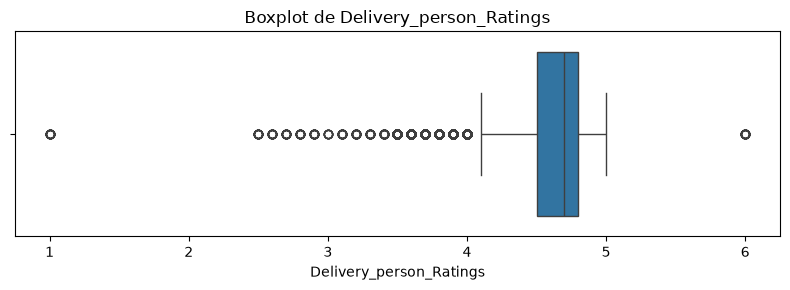

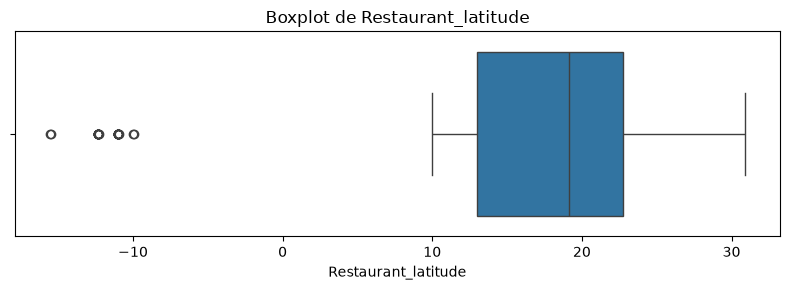

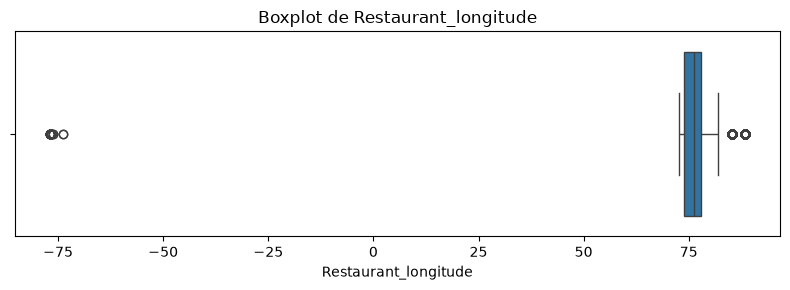

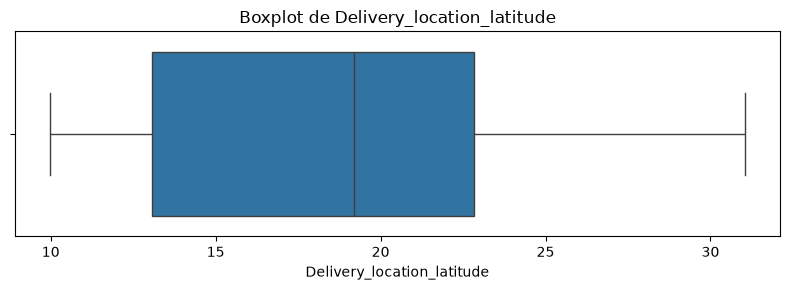

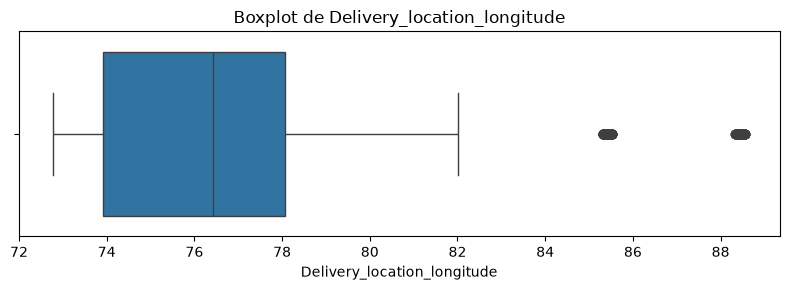

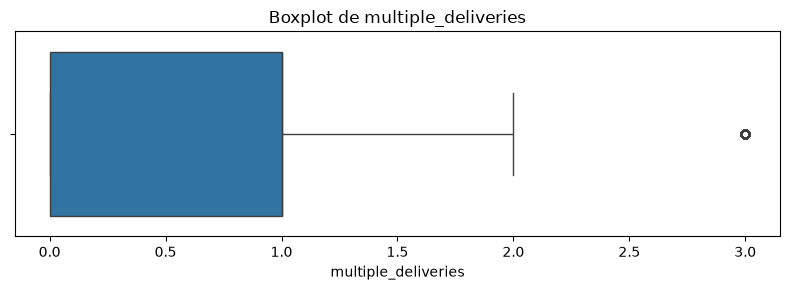

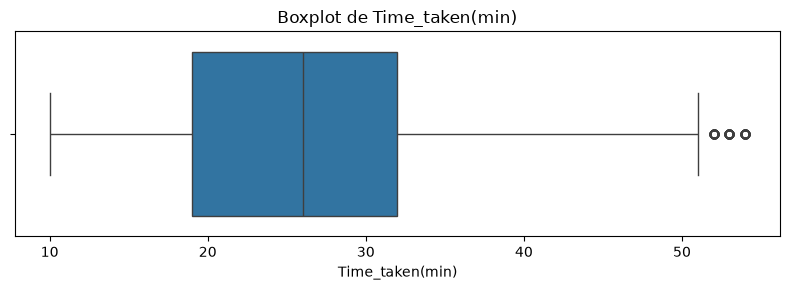

In [549]:
outlier_cols = num_cols + [target]

for col in outlier_cols:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot de {col}")
    plt.tight_layout()
    plt.show()

In [550]:
outlier_summary = []
for col in outlier_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary.append({
        "colonne": col, "Q1": q1, "Q3": q3, "IQR": iqr,
        "borne_basse": lower, "borne_haute": upper,
        "nb_outliers": n_outliers,
        "pct_outliers": round(n_outliers / len(df) * 100, 2)
    })

pd.DataFrame(outlier_summary)

,colonne,Q1,Q3,IQR,borne_basse,borne_haute,nb_outliers,pct_outliers
0,Delivery_person_Ratings,4.500000,4.800000,0.300000,4.050000,5.250000,2154,5.41
1,Restaurant_latitude,12.980410,22.753659,9.773249,-1.679464,37.413533,31,0.08
2,Restaurant_longitude,73.842527,78.011544,4.169017,67.589002,84.265069,3243,8.14
3,Delivery_location_latitude,13.060221,22.835835,9.775614,-1.603200,37.499256,0,0.00
4,Delivery_location_longitude,73.920626,78.060165,4.139539,67.711318,84.269474,3212,8.06
5,multiple_deliveries,0.000000,1.000000,1.000000,-1.500000,2.500000,302,0.76
6,Time_taken(min),19.000000,32.000000,13.000000,-0.500000,51.500000,235,0.59


## 12. Sauvegarde du dataset nettoyé
Le fichier nettoyé (39 831 lignes, 11 colonnes, 0 valeur manquante) est sauvegardé dans `data/silver/`. Le fichier brut original reste inchangé dans `data/bronze/`.

In [551]:
df.to_csv(DELIVERY_DATA_S, index=False)
print("Fichier sauvegardé :", DELIVERY_DATA_S)
df.info()

Fichier sauvegardé : C:\Users\Elkerymy-Mohamed\Study-DevAI\DeliveryETA\data\silver\delivery_data.csv
<class 'pandas.core.frame.DataFrame'>
Index: 39831 entries, 0 to 45592
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           39831 non-null  object 
 1   Delivery_person_Ratings      39831 non-null  Float64
 2   Restaurant_latitude          39831 non-null  float64
 3   Restaurant_longitude         39831 non-null  float64
 4   Delivery_location_latitude   39831 non-null  float64
 5   Delivery_location_longitude  39831 non-null  float64
 6   Weatherconditions            39831 non-null  object 
 7   Road_traffic_density         39831 non-null  object 
 8   Type_of_vehicle              39831 non-null  object 
 9   multiple_deliveries          39831 non-null  Int64  
 10  Time_taken(min)              39831 non-null  Int64  
dtypes: Float64(1), Int64(2), float64(4),

## 13. Conclusion générale

Le jeu de données brut contenait **45 593 lignes et 20 colonnes**. Après suppression de 9 colonnes non pertinentes, correction du texte parasite (préfixes `"(min) "`, `"conditions "`, espaces parasites, faux `"NaN"` textuels), filtrage de 5 762 lignes aux coordonnées GPS invalides (océan), imputation de 4 colonnes (mode pour les catégorielles, médiane/mode pour les numériques) et vérification de l'absence de doublons et de valeurs aberrantes critiques, le jeu de données nettoyé compte **39 831 lignes et 11 colonnes, sans aucune valeur manquante**.

Il est prêt pour l'analyse exploratoire du Jour 2 (statistiques descriptives, distribution de la cible, corrélations, feature engineering).